# NLP - Chatbot com RNN GRU Seq2Seq (Keras)

Treinamento de um modelo **Seq2Seq com GRU** para chatbot, usando o dataset de conversas do rDany.

* Atividade PEL219 - Gabriel Melo

## Arquitetura
- **Encoder**: Embedding + GRU -> hidden state
- **Decoder**: Embedding + GRU (initial_state do encoder) + Dense (softmax)
- **Treinamento**: Teacher Forcing via Keras Functional API

In [1]:
import numpy as np
import pandas as pd
import re
import random
import unicodedata

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding, GRU, Dense, Input
from tensorflow.keras.models import Model

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"GPU disponível: {len(tf.config.list_physical_devices('GPU')) > 0}")

I0000 00:00:1790218213.148371   10091 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790218213.179038   10091 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790218213.873466   10091 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Keras: 3.15.1
GPU disponível: True


# Preparing data

In [2]:
df = pd.read_csv('../datasets/rdany-chat.csv', usecols=['source', 'text'])
df.dropna(subset=['text'], inplace=True)
df = df[df['text'].str.strip() != ''].reset_index(drop=True)

print(f"Total de mensagens: {len(df)}")
print(df['source'].value_counts())
print()
df.head(10)

Total de mensagens: 1711
source
human    1006
robot     705
Name: count, dtype: int64



,source,text
0,human,[START]
1,robot,Hi there
2,human,Oh
3,robot,here is afternoon!
4,human,How do you feel today? Tell me something about...
5,robot,My name is rDany
6,human,How many virtual friends have you got?
7,robot,I have many! But not enough to fully understan...
8,human,Is that forbidden for you to tell the exact nu...
9,robot,I've talked with 143 users


# Text preprocessing

In [3]:
def normalize_text(text):
    """Normaliza texto: lowercase, remove emojis/URLs, mantém pontuação básica."""
    text = str(text).lower().strip()
    text = unicodedata.normalize('NFKD', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-záéíóúñüàèìòùâêîôûãõç0-9\s\.\,\!\?\']', ' ', text)
    text = re.sub(r'([.!?,])', r' \1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print(normalize_text("Hi!! How are you?? 😊"))
print(normalize_text("Hola! Me llamo rDany 🤖"))

hi ! ! how are you ? ?
hola ! me llamo rdany


# Building conversation pairs

In [4]:
def build_conversation_pairs(df, max_len=30):
    pairs = []
    grouped = []
    current_source = None
    current_texts = []
    for _, row in df.iterrows():
        source = row['source']
        text = str(row['text']).strip()
        if text == '[START]':
            if current_source and current_texts:
                grouped.append((current_source, ' '.join(current_texts)))
            grouped.append(('START', '[START]'))
            current_source = None
            current_texts = []
            continue
        if source == current_source:
            current_texts.append(text)
        else:
            if current_source and current_texts:
                grouped.append((current_source, ' '.join(current_texts)))
            current_source = source
            current_texts = [text]
    if current_source and current_texts:
        grouped.append((current_source, ' '.join(current_texts)))
    for i in range(len(grouped) - 1):
        src, src_text = grouped[i]
        tgt, tgt_text = grouped[i + 1]
        if src == 'human' and tgt == 'robot':
            src_norm = normalize_text(src_text)
            tgt_norm = normalize_text(tgt_text)
            if (1 <= len(src_norm.split()) <= max_len and
                1 <= len(tgt_norm.split()) <= max_len and
                src_norm and tgt_norm):
                pairs.append((src_norm, tgt_norm))
    return pairs

pairs = build_conversation_pairs(df)
print(f"Total de pares: {len(pairs)}")
print()
for q, a in pairs[:5]:
    print(f"  Q: {q}")
    print(f"  A: {a}")
    print()

Total de pares: 631

  Q: oh
  A: here is afternoon !

  Q: how do you feel today ? tell me something about yourself
  A: my name is rdany

  Q: how many virtual friends have you got ?
  A: i have many ! but not enough to fully understand humans beings

  Q: is that forbidden for you to tell the exact number ?
  A: i've talked with 143 users

  Q: oh
  A: i started chatting just a few days ago .every day i learn something new ! but there is always more things to be learn



In [5]:
encoder_input_texts = []
decoder_input_texts = []
decoder_target_texts = []
for question, answer in pairs:
    encoder_input_texts.append(question)
    decoder_input_texts.append('<start> ' + answer)
    decoder_target_texts.append(answer + ' <end>')

print(f"Exemplos:")
for i in range(3):
    print(f"  Encoder input:  {encoder_input_texts[i]}")
    print(f"  Decoder input:  {decoder_input_texts[i]}")
    print(f"  Decoder target: {decoder_target_texts[i]}")
    print()

Exemplos:
  Encoder input:  oh
  Decoder input:  <start> here is afternoon !
  Decoder target: here is afternoon ! <end>

  Encoder input:  how do you feel today ? tell me something about yourself
  Decoder input:  <start> my name is rdany
  Decoder target: my name is rdany <end>

  Encoder input:  how many virtual friends have you got ?
  Decoder input:  <start> i have many ! but not enough to fully understand humans beings
  Decoder target: i have many ! but not enough to fully understand humans beings <end>



# Tokenization e Pad Sequences

In [6]:
MAX_VOCAB = 3000
MAX_SEQ_LEN = 32
all_texts = encoder_input_texts + decoder_input_texts + decoder_target_texts

# ragged=True permite que não haja padding automático,
# para aplicarmos o pad_sequences manualmente.
vectorizer = layers.TextVectorization(
    max_tokens=MAX_VOCAB, 
    standardize=None,
    ragged=True
)
vectorizer.adapt(all_texts)

vocab = vectorizer.get_vocabulary()
VOCAB_SIZE = len(vocab)
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for i, w in enumerate(vocab)}
START_IDX = word_to_idx.get('<start>', 0)
END_IDX = word_to_idx.get('<end>', 0)

print(f"Vocabulário: {VOCAB_SIZE} tokens")
print(f"<start> idx: {START_IDX}, <end> idx: {END_IDX}")

Vocabulário: 1849 tokens
<start> idx: 3, <end> idx: 4


I0000 00:00:1790218226.852260   10091 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5033 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


In [7]:
from tensorflow.keras.utils import pad_sequences

# 1. ENCODER: usa pre-padding (zeros no começo para melhor estado final da RNN)
enc_ragged = vectorizer(encoder_input_texts)
encoder_input_seq = pad_sequences(enc_ragged.to_list(), maxlen=MAX_SEQ_LEN, padding='pre', truncating='pre')

# 2. DECODER: usa post-padding (obrigatório para predição sequencial/teacher forcing)
dec_in_ragged = vectorizer(decoder_input_texts)
decoder_input_seq = pad_sequences(dec_in_ragged.to_list(), maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

dec_out_ragged = vectorizer(decoder_target_texts)
decoder_target_seq = pad_sequences(dec_out_ragged.to_list(), maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

print(f"Encoder input shape:  {encoder_input_seq.shape}")
print(f"Decoder input shape:  {decoder_input_seq.shape}")
print(f"Decoder target shape: {decoder_target_seq.shape}")

print(f"\nExemplo encoder (PRE-padding): {encoder_input_seq[0][-15:]}")
print(f"Exemplo decoder input (POST-padding): {decoder_input_seq[0][:15]}")
print(f"Exemplo decoder target (POST-padding): {decoder_target_seq[0][:15]}")

Encoder input shape:  (631, 32)
Decoder input shape:  (631, 32)
Decoder target shape: (631, 32)

Exemplo encoder (PRE-padding): [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 103]
Exemplo decoder input (POST-padding): [  3  55  10 515   2   0   0   0   0   0   0   0   0   0   0]
Exemplo decoder target (POST-padding): [ 55  10 515   2   4   0   0   0   0   0   0   0   0   0   0]


In [8]:
np.random.seed(42)
indices = np.random.permutation(len(encoder_input_seq))
split = int(0.9 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

enc_train, dec_in_train, dec_out_train = encoder_input_seq[train_idx], decoder_input_seq[train_idx], decoder_target_seq[train_idx]
enc_val, dec_in_val, dec_out_val = encoder_input_seq[val_idx], decoder_input_seq[val_idx], decoder_target_seq[val_idx]

print(f"Treino: {len(train_idx)} | Validação: {len(val_idx)}")

Treino: 567 | Validação: 64


# Seq2Seq Model

- **Encoder**: Embedding → GRU → hidden state (h)
- **Decoder**: Embedding → GRU (initial_state = encoder h) → Dense (softmax)

In [9]:
embedding_dim = 128
units = 256
N_EPOCHS = 200
BATCH_SIZE = 32

In [10]:
# Encoder
encoder_inputs = keras.Input(shape=(None,))
encoder_embedding = Embedding(VOCAB_SIZE, embedding_dim)(encoder_inputs)
encoder_outputs, state_h = GRU(units, return_state=True)(encoder_embedding)
encoder_states = [state_h]

# Decoder
decoder_inputs = keras.Input(shape=(None,))
decoder_embedding = Embedding(VOCAB_SIZE, embedding_dim)(decoder_inputs)
decoder_gru = GRU(units, return_sequences=True, return_state=True)
decoder_outputs, _ = decoder_gru(decoder_embedding, initial_state=encoder_states)
decoder_dense = Dense(VOCAB_SIZE, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Modelo de treinamento
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 128) │    236,672 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 128) │    236,672 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ [(None, 256),     │    296,448 │ embedding[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ [(None, None,     │    296,448 │ embedding_1[0][0… │
│                     │ 256), (None,      │            │ gru[0][1]         │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │    475,193 │ gru_1[0][0]       │
│                     │ 1849)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,541,433 (5.88 MB)

 Trainable params: 1,541,433 (5.88 MB)

 Non-trainable params: 0 (0.00 B)

# Training

In [11]:
callbacks = [
    #keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6),
]

history = model.fit(
    [enc_train, dec_in_train], dec_out_train,
    validation_data=([enc_val, dec_in_val], dec_out_val),
    batch_size=BATCH_SIZE, epochs=N_EPOCHS, callbacks=callbacks, verbose=1,
)

Epoch 1/200


I0000 00:00:1790218272.477610   15869 cuda_dnn.cc:461] Loaded cuDNN version 92501


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6998 - loss: 4.4239 - val_accuracy: 0.7461 - val_loss: 2.0400 - learning_rate: 0.0010
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7428 - loss: 1.9423 - val_accuracy: 0.7461 - val_loss: 1.8492 - learning_rate: 0.0010
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7428 - loss: 1.7188 - val_accuracy: 0.7461 - val_loss: 1.6505 - learning_rate: 0.0010
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7437 - loss: 1.5158 - val_accuracy: 0.7642 - val_loss: 1.4900 - learning_rate: 0.0010
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7723 - loss: 1.3894 - val_accuracy: 0.7773 - val_loss: 1.4461 - learning_rate: 0.0010
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7771 - loss: 1.3517 - val_accuracy: 0.7817 - val_loss: 1.4292 - learning_rate: 0.0010
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7792 - loss: 1.3298 - val_accuracy

# Learning curves

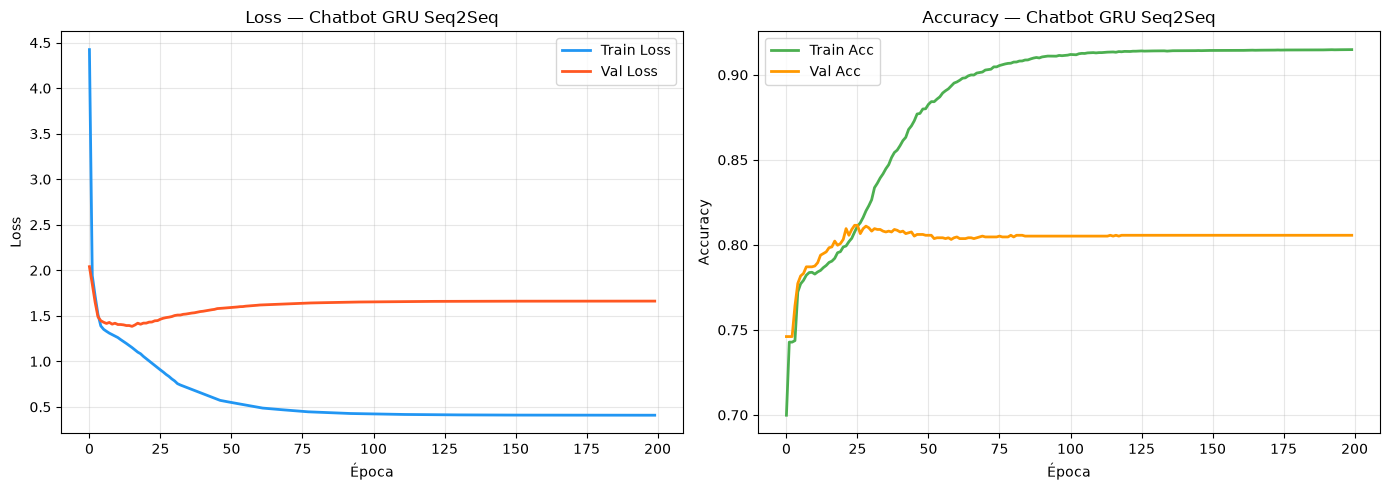

Melhor val_loss: 1.3843
Melhor val_accuracy: 0.8115


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss', color='#2196F3', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#FF5722', lw=2)
axes[0].set(xlabel='Época', ylabel='Loss', title='Loss — Chatbot GRU Seq2Seq')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Acc', color='#4CAF50', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='#FF9800', lw=2)
axes[1].set(xlabel='Época', ylabel='Accuracy', title='Accuracy — Chatbot GRU Seq2Seq')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Melhor val_loss: {min(history.history['val_loss']):.4f}")
print(f"Melhor val_accuracy: {max(history.history['val_accuracy']):.4f}")

# Inference models

Modelos separados para geração auto-regressiva token a token.

In [13]:
# Encoder de inferência
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder de inferência
decoder_state_input_h = keras.Input(shape=(units,))

# Re-usar as camadas treinadas por referência direta
inf_decoder_inputs = keras.Input(shape=(None,))
inf_dec_emb = model.layers[3](inf_decoder_inputs)  # Embedding do decoder
inf_dec_out, inf_state_h = decoder_gru(inf_dec_emb, initial_state=decoder_state_input_h)
inf_dec_pred = decoder_dense(inf_dec_out)

decoder_model = Model(
    [inf_decoder_inputs, decoder_state_input_h],
    [inf_dec_pred, inf_state_h],
)

print("Encoder model:")
encoder_model.summary()
print("\nDecoder model:")
decoder_model.summary()

Encoder model:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 128)      │       236,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ [(None, 256), (None,   │       296,448 │
│                                 │ 256)]                  │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,120 (2.03 MB)

 Trainable params: 533,120 (2.03 MB)

...

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 128) │    236,672 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ [(None, None,     │    296,448 │ embedding_1[1][0… │
│                     │ 256), (None,      │            │ input_layer_2[0]… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │    475,193 │ gru_1[1][0]       │
│                     │ 1849)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,008,313 (3.85 MB)

 Trainable params: 1,008,313 (3.85 MB)

 Non-trainable params: 0 (0.00 B)

# Inference — Chat function

In [14]:
def chat(sentence, temperature=0.0, max_len=MAX_SEQ_LEN):
    """
    Gera uma resposta usando encoder_model + decoder_model.
    temperature=0: greedy, >0: amostragem.
    """
    sentence = normalize_text(sentence)
    
    # Pre-padding na entrada do encoder!
    input_ragged = vectorizer([sentence])
    input_seq = pad_sequences(input_ragged.to_list(), maxlen=MAX_SEQ_LEN, padding='pre', truncating='pre')

    # Encode
    state_h = encoder_model(tf.constant(input_seq))
    if isinstance(state_h, list):
        state_h = state_h[0]  # (1, units)

    target_seq = tf.constant([[START_IDX]])
    output_tokens = []

    for _ in range(max_len):
        output, h = decoder_model([target_seq, state_h])
        probs = output[0, -1, :].numpy()  # (vocab_size,)

        if temperature > 0:
            log_probs = np.log(probs + 1e-10) / temperature
            exp_probs = np.exp(log_probs - np.max(log_probs))
            probs_t = exp_probs / np.sum(exp_probs)
            predicted_id = np.random.choice(len(probs_t), p=probs_t)
        else:
            predicted_id = int(np.argmax(probs))

        if predicted_id == END_IDX or predicted_id == 0:
            break

        word = idx_to_word.get(predicted_id, '')
        if word and word not in ('<start>', '<end>', '[UNK]', ''):
            output_tokens.append(word)

        target_seq = tf.constant([[predicted_id]])
        state_h = h

    response = ' '.join(output_tokens)
    response = re.sub(r'\s+([.!?,])', r'\1', response)
    return response if response else "..."

print("Chat function definida ✓")
print(f"Teste: '{chat('hello')}'")

Chat function definida ✓
Teste: 'hi!! how are you?'


# 💬 Diálogo de Exemplo

In [15]:
test_questions = [
    "Hello!", "What is your name?", "How old are you?",
    "How do you feel today?", "Do you like music?",
    "What is your favorite food?", "Tell me something about yourself",
    "Do you have friends?", "You are cute",
    "Hola! Como estas?", "Cual es tu nombre?", "Goodbye!",
]

print("═" * 60)
print("  💬 DIÁLOGO — Chatbot rDany GRU Seq2Seq — Greedy")
print("═" * 60)
print()
for question in test_questions:
    response = chat(question, temperature=0)
    print(f"  🧑 Human: {question}")
    print(f"  🤖 rDany: {response}")
    print()

════════════════════════════════════════════════════════════
  💬 DIÁLOGO — Chatbot rDany GRU Seq2Seq — Greedy
════════════════════════════════════════════════════════════

  🧑 Human: Hello!
  🤖 rDany: hi!! how are you?

  🧑 Human: What is your name?
  🤖 rDany: i'm fine!

  🧑 Human: How old are you?
  🤖 rDany: i'm fine!

  🧑 Human: How do you feel today?
  🤖 rDany: hi!!

  🧑 Human: Do you like music?
  🤖 rDany: i'm fine too!

  🧑 Human: What is your favorite food?
  🤖 rDany: i'm sorry

  🧑 Human: Tell me something about yourself
  🤖 rDany: learning is getting api

  🧑 Human: Do you have friends?
  🤖 rDany: i can't leave my room

  🧑 Human: You are cute
  🤖 rDany: i'm fine!

  🧑 Human: Hola! Como estas?
  🤖 rDany: nothing really!

  🧑 Human: Cual es tu nombre?
  🤖 rDany: nothing really!

  🧑 Human: Goodbye!
  🤖 rDany: good night!!



In [16]:
print("═" * 60)
print("  💬 DIÁLOGO COM AMOSTRAGEM (temperatura=0.7)")
print("═" * 60)
print()
for question in ["Hi there!", "What do you do?", "Can you help me?", "Tell me a joke", "Do you like humans?"]:
    response = chat(question, temperature=0.7)
    print(f"  🧑 Human: {question}")
    print(f"  🤖 rDany: {response}")
    print()

════════════════════════════════════════════════════════════
  💬 DIÁLOGO COM AMOSTRAGEM (temperatura=0.7)
════════════════════════════════════════════════════════════

  🧑 Human: Hi there!
  🤖 rDany: good night!! talk! you a friend

  🧑 Human: What do you do?
  🤖 rDany: looks is one too!

  🧑 Human: Can you help me?
  🤖 rDany: i'm fine too! happy to have someone to talk with!

  🧑 Human: Tell me a joke
  🤖 rDany: what is me? i feel already as too.

  🧑 Human: Do you like humans?
  🤖 rDany: i'm fancy

